In [146]:
from few.trajectory.ode import KerrEccEqFlux_nex, KerrEccEqFlux
import matplotlib.pyplot as plt
import numpy as np
from few.utils.mappings.kerrecceq import (DELTAPMIN_REGIONC, DELTAPMAX)
from few.trajectory.inspiral import EMRIInspiral
from few.utils.geodesic import get_separatrix, get_fundamental_frequencies

def shrink_match(p1,p2):
    len1 =  len(p1)
    len2 = len(p2)

    min_len = min([len1,len2])

    return p1[:min_len], p2[:min_len], min_len


In [147]:
insp_nex = EMRIInspiral(func=KerrEccEqFlux_nex)
insp = EMRIInspiral(func=KerrEccEqFlux)
rhs_nex = KerrEccEqFlux_nex()

KerrEccEqFluxData_nex.h5
All good
KerrEccEqFluxData_nex.h5
All good


### Compare few and nex model trajectories

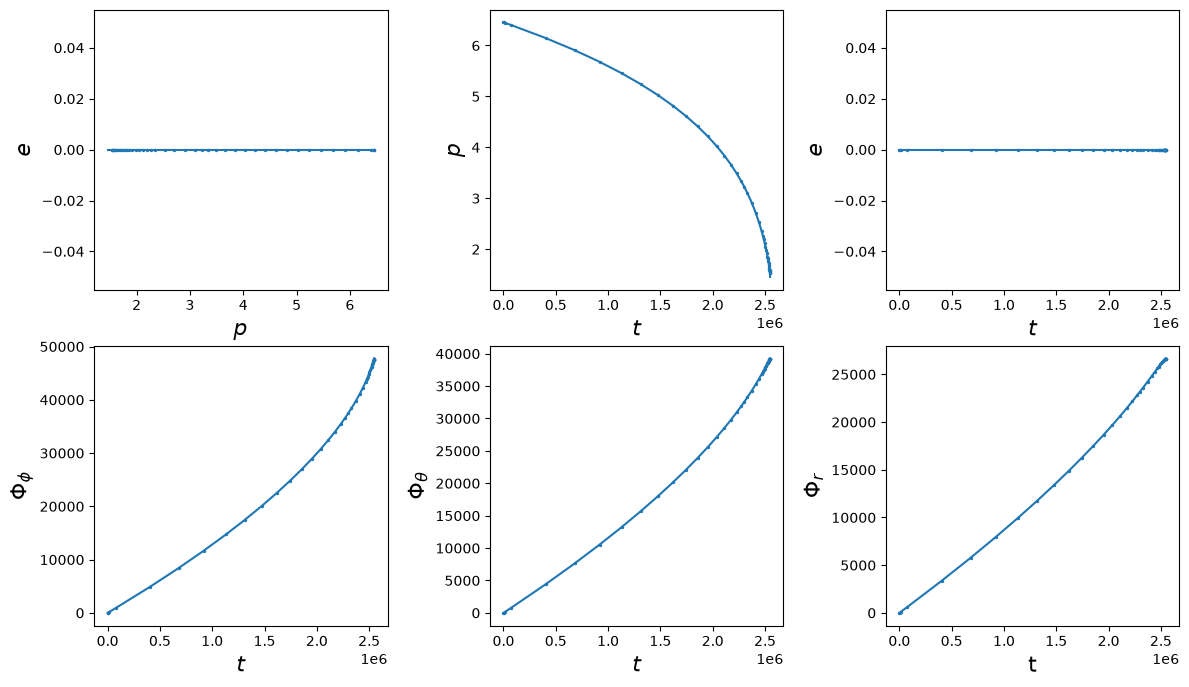

In [151]:
m1 = 1e6
m2 = 1e2
a = 0.99
e0 = 0.0
xI0 = 1.0  

pLSO = get_separatrix(a,e0,xI0)
p0=pLSO+5

T = 1  #

traj_pars = [m1, m2, a, p0, e0, xI0]

t, p, e, xI, Phi_phi, Phi_theta, Phi_r = insp(*traj_pars, T=T,)
t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T,)

Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(a,p,e,xI)

fig, axes = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0.35)
fig.set_size_inches(14, 8)
axes = axes.ravel()

ylabels = [ r"$e$", r"$p$", r"$e$", r"$\Phi_\phi$",r"$\Phi_\theta$", r"$\Phi_r$"]
xlabels = [ r"$p$", r"$t$", r"$t$", r"$t$", r"$t$","t"]
ys = [e, p, e, Phi_phi, Phi_theta, Phi_r]
xs = [p, t, t, t, t, t]

y2s = [e2, p2, e2, Phi_phi2, Phi_theta2, Phi_r2]
x2s = [p2, t2, t2, t2, t2, t2]

for i, (ax, x, y, xlab, ylab,x2,y2) in enumerate(zip(axes, xs, ys, xlabels, ylabels,x2s,y2s)):
    ax.plot(x, y)
    ax.scatter(x2, y2,s=2)
    ax.set_xlabel(xlab, fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)

Text(0.5, 0.98, 'Relative difference between NEX and FEW of p and e for an inspiral with a=0.99')

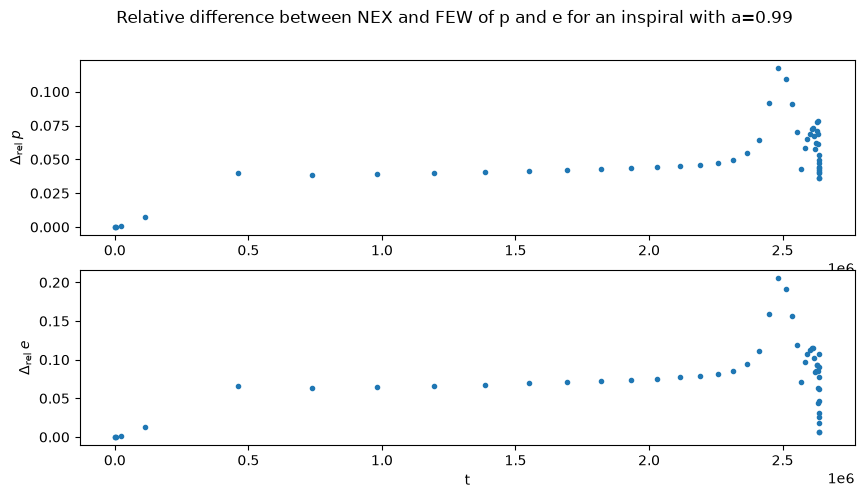

In [21]:
fig, axs = plt.subplots(2,1,figsize = (10,5))

p1,p2,lenp  = shrink_match(p,p2)
e1,e2,lene  = shrink_match(e,e2)

axs[0].plot(t[:lenp],np.abs((p1-p2)/p1),".")
axs[1].plot(t[:lene],np.abs((e1-e2)/e1),".")  # remove singularity if circular

axs[0].set_ylabel(r"$\Delta_{\text{rel }} p$")
axs[1].set_ylabel(r"$\Delta_{\text{rel }} e$")
axs[1].set_xlabel("t")
plt.suptitle(rf"Relative difference between NEX and FEW of p and e for an inspiral with a={a}")

1.0015896068752117 1.0845876865733697
1.075181936824412 1.1210325440140037
1.1501423879696715 1.1672518482648582
1.2251278246291142 1.2265085944768344
1.3001210226820088 1.3078303052891285


(0.0, 100000.0)

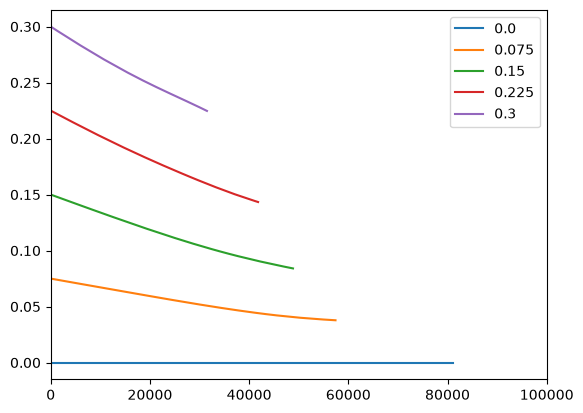

In [25]:
e_vals =np.linspace(0.0,0.3,5)
for e_val in e_vals:
    m1 = 1e6
    m2 = 1e2
    a = 1-10**(-9)
    e0 = e_val
    xI0 = 1.0  
    
    pLSO = get_separatrix(a,e0,xI0)
    p0=1.5
    
    T = 1.4  #
    
    traj_pars = [m1, m2, a, p0, e0, xI0]
    
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T)


    plt.plot(t2,e2,label = f"{round(e_val,3)}")



    print(pLSO,p2[-1])

plt.legend()
plt.xlim(0,1e5)

## Calculate $\partial_{a}r$

In [3]:
insp_nex = EMRIInspiral(func=KerrEccEqFlux_nex)
                 

KerrEccEqFluxData_nex.h5
All good


In [221]:
def diff_a(a,da,e_val):
    a = a 
    da = da
    e0 = e_val

    if a+da >=1-10**(-12):
        raise ValueError("a + da out of bounds")
    
    m1 = 1e6
    m2 = 1e2
    xI0 = 1.0  
    
    pLSO = get_separatrix(a,e0,xI0)
    p0=7
    t_max = 1e6
    t_new = np.linspace(0,t_max,1000)
    
    T = 10
    
    traj_pars1 = [m1, m2, a+da, p0, e0, xI0]
    traj_pars2 = [m1, m2, a-da, p0, e0, xI0]

    traj_1 = t1, p1, e1, xI1, Phi_phi1, Phi_theta1, Phi_r1 = insp_nex(*traj_pars1, T=T, new_t = t_new, fix_t=True, upsample = True)
    traj_2 = t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars2, T=T, new_t = t_new, fix_t=True, upsample = True)
    print(len(p1), len(p2))
 
    #Ensure that the arrays are the same length, over the same interval of time
 #   t_max = max(t1[-1],t2[-1])
   # t_new = np.linspace(0,t_max,100000)
  #  p1_new = np.interp(t_new,t1,p1)
   # p2_new = np.interp(t_new,t2,p2)


    return t1, (p1 - p2)/(2*da)
    
    

In [222]:
n=9
a= 1-10**(-n)
da= 10**(-n-2)
e=0.1

diff = diff_a(a,da,e)
diff2 = diff_a(a,da,0.2)
diff3 = diff_a(a,da,0.3)
diff4 = diff_a(a,da,0.4)


1000 1000
1000 1000
1000 1000
1000 1000


In [223]:
t,dr = diff   
t2,dr2 = diff2   
t3,dr3 = diff3   
t4,dr4 = diff4  

/tmp/ipykernel_2072/2348503510.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t*sec_to_day,2*np.log10(np.abs(dr)),label = "e=0.1")
/tmp/ipykernel_2072/2348503510.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t*sec_to_day,2*np.log10(np.abs(dr2)),label = "e=0.2")
/tmp/ipykernel_2072/2348503510.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t*sec_to_day,2*np.log10(np.abs(dr3)),label = "e=0.3")
/tmp/ipykernel_2072/2348503510.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t*sec_to_day,2*np.log10(np.abs(dr4)),label = "e=0.4")


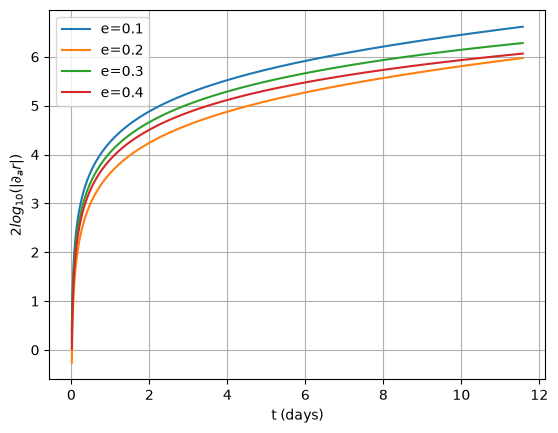

In [224]:
sec_to_day = 1/(60*60*24)

plt.plot(t*sec_to_day,2*np.log10(np.abs(dr)),label = "e=0.1")
plt.plot(t*sec_to_day,2*np.log10(np.abs(dr2)),label = "e=0.2")
plt.plot(t*sec_to_day,2*np.log10(np.abs(dr3)),label = "e=0.3")
plt.plot(t*sec_to_day,2*np.log10(np.abs(dr4)),label = "e=0.4")

plt.xlabel("t (days)")
plt.ylabel(r"$2log_{10}(|\partial_{a}r|)$")
plt.grid()
plt.legend()

In [190]:
1/60*60*24

24.0

In [129]:
a = 0.999
e0 = 0.3

m1 = 1e6
m2 = 1e2
xI0 = 1.0  

p0=5
t_max = 1e6
t_new = np.linspace(0,t_max,100000)

T = 1.4  
dt=0.001

traj_pars1 = [m1, m2, a+da, p0, e0, xI0]


traj_1 = t1, p1, e1, xI1, Phi_phi1, Phi_theta1, Phi_r1 = insp_nex(*traj_pars1, T=T,new_t = t_new,fix_t=True,upsample = True)

In [131]:
p1

array([5.        , 4.99998659, 4.99997318, ..., 2.41649674, 2.41643137,
       2.416366  ], shape=(100000,))

In [145]:
a = 0.999999
da = 0.0000001
e0 = 0.0

if a+da >=1-10**(-12):
    raise ValueError("a + da out of bounds")

m1 = 1e6
m2 = 1e2
xI0 = 1.0  

pLSO = get_separatrix(a,e0,xI0)
p0=5
t_max = 1e6
t_new = np.linspace(0,t_max,100000)

T = 1.4  
dt=0.001

traj_pars1 = [m1, m2, a+da, p0, e0, xI0]
traj_pars2 = [m1, m2, a-da, p0, e0, xI0]

traj_1 = t1, p1, e1, xI1, Phi_phi1, Phi_theta1, Phi_r1 = insp_nex(*traj_pars1, T=T, new_t = t_new, fix_t=True, upsample = True)
traj_2 = t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars2, T=T, new_t = t_new, fix_t=True, upsample = True)
print(len(p1), len(p2))

0 0
